In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import os

import kagglehub

path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
csv_path = os.path.join(path, "healthcare-dataset-stroke-data.csv")

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.makedirs(os.path.join(project_root, 'data', 'processed'), exist_ok=True)
os.makedirs(os.path.join(project_root, 'images'), exist_ok=True)

In [2]:
df = pd.read_csv(csv_path)

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB
None


In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [7]:
len(df)

5110

In [8]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [9]:
df[df["bmi"].isna()]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5039,42007,Male,41.0,0,0,No,Private,Rural,70.15,NaN,formerly smoked,0
5048,28788,Male,40.0,0,0,Yes,Private,Urban,191.15,NaN,smokes,0
5093,32235,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,NaN,smokes,0
5099,7293,Male,40.0,0,0,Yes,Private,Rural,83.94,NaN,smokes,0


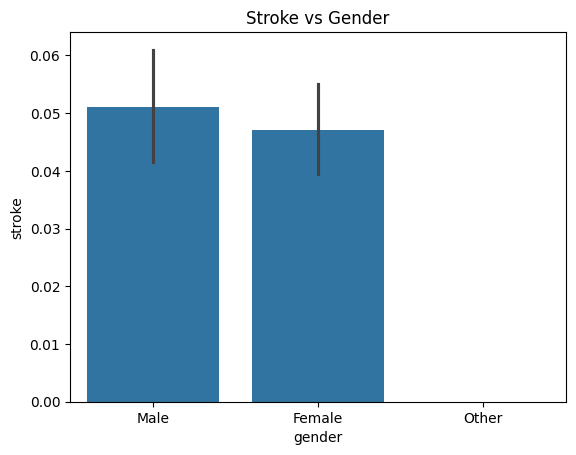

In [10]:
plt.title("Stroke vs Gender")
sns.barplot(x=df["gender"], y=df["stroke"])
plt.savefig("../images/stroke_vs_gender.png")
plt.show()

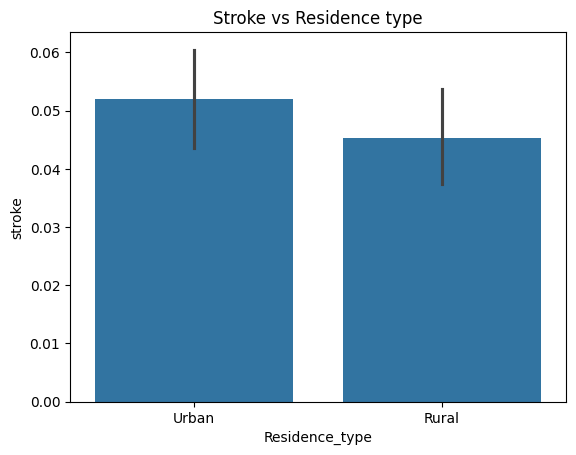

In [11]:
plt.title("Stroke vs Residence type")
sns.barplot(x=df["Residence_type"], y=df["stroke"])
plt.savefig("../images/stroke_vs_residence_type.png")
plt.show()

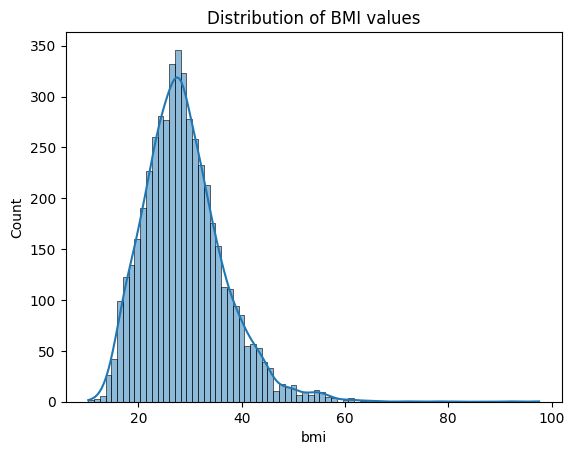

In [12]:
plt.title("Distribution of BMI values")
sns.histplot(df["bmi"], kde=True)
plt.savefig("../images/distribution_of_bmi.png")
plt.show()

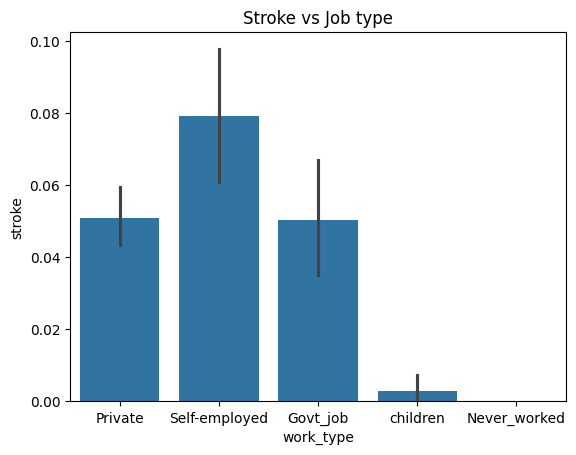

In [13]:
plt.title("Stroke vs Job type")
sns.barplot(x=df["work_type"], y=df["stroke"])
plt.savefig("../images/stroke_vs_job_type.png")
plt.show()

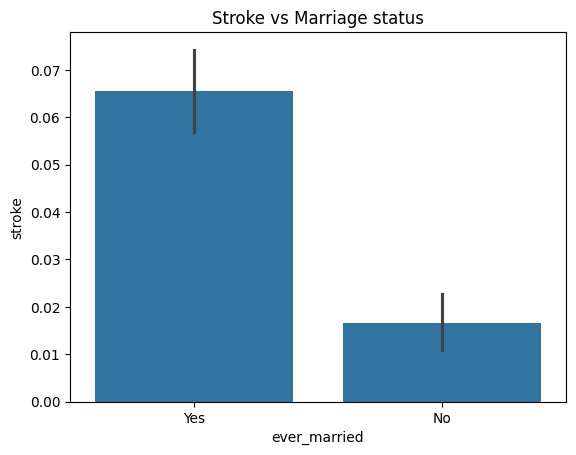

In [14]:
plt.title("Stroke vs Marriage status")
sns.barplot(x=df["ever_married"], y=df["stroke"])
plt.savefig("../images/stroke_vs_marriage_status.png")
plt.show()

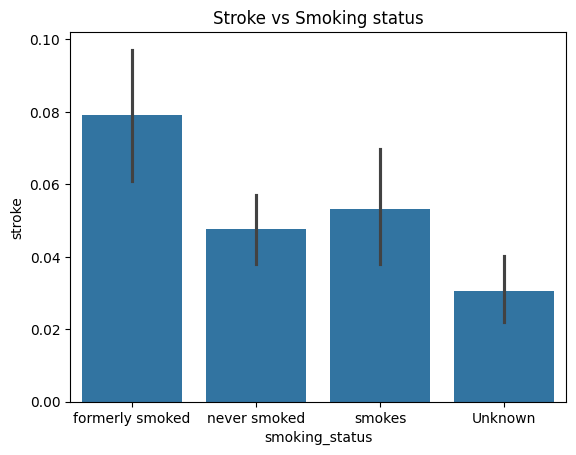

In [15]:
plt.title("Stroke vs Smoking status")
sns.barplot(x=df["smoking_status"], y=df["stroke"])
plt.savefig("../images/stroke_vs_smoking_status.png")
plt.show()

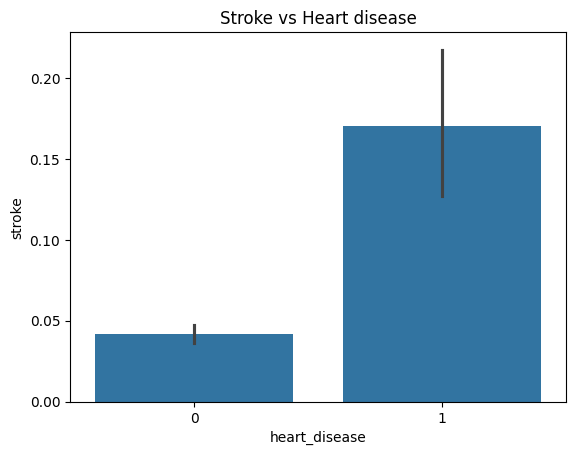

In [16]:
plt.title("Stroke vs Heart disease")
sns.barplot(x=df["heart_disease"], y=df["stroke"])
plt.savefig("../images/stroke_vs_heart_disease.png")
plt.show()

In [17]:
df["age"].min()

np.float64(0.08)

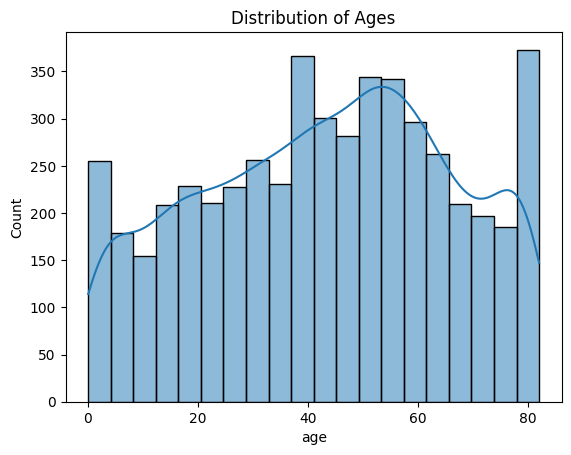

In [18]:
plt.title("Distribution of Ages")
sns.histplot(df["age"], kde=True)
plt.savefig("../images/distribution_of_ages.png")
plt.show()

In [19]:
df['bmi_group'] = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, float('inf')], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

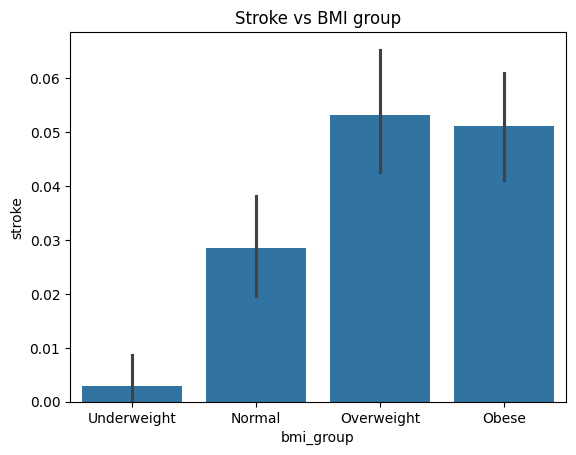

In [20]:
plt.title("Stroke vs BMI group")
sns.barplot(x=df["bmi_group"], y=df["stroke"])
plt.savefig("../images/stroke_vs_bmi.png")
plt.show()

In [21]:
df = df.drop(columns=["id", "bmi_group"])

In [22]:
df['smoking_status'] = df['smoking_status'].replace('Unknown', np.nan)

In [23]:
X = df.drop(columns=["stroke"])
y = df["stroke"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [25]:
X_train.to_csv(os.path.join(project_root, 'data', 'processed', 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(project_root, 'data', 'processed', 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(project_root, 'data', 'processed', 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(project_root, 'data', 'processed', 'y_test.csv'), index=False)

print("All files saved successfully")

All files saved successfully
